In [517]:
# ==========================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.preprocessing import MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [518]:
# ==========================================
# LECTURA DE ARCHIVO Y EXPLORACIÓN DE DATOS
# ==========================================

# Leer dataset proveniente del csv
vg_data = pd.read_csv("../dato.csv")

print('_'*40)

#Leer ultimos datos del dataset
vg_data.tail()

print('_'*40)

#Leer info general del dataset
vg_data.info()

print('_'*40)

#Leer cuantos datos hay en cada columna
vg_data.count()

print('_'*40)

________________________________________
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7112 entries, 0 to 7111
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Platform            7112 non-null   object
 1   Genre               7112 non-null   object
 2   Publisher           7112 non-null   object
 3   NA_Sales            7112 non-null   object
 4   EU_Sales            7112 non-null   object
 5   JP_Sales            7112 non-null   object
 6   Other_Sales         7112 non-null   object
 7   Global_Sales        7112 non-null   object
 8   Rating              7112 non-null   object
 9   Critic_Score_Class  7112 non-null   object
dtypes: object(10)
memory usage: 555.8+ KB
________________________________________
________________________________________


In [519]:
# ==========================================
# REFACTORIZACIÓN DE DATOS
# ==========================================

# Eliminar filas con valores nulos o vacios para evitar errores de entrenamiento
vg_data = vg_data.dropna()

# Reemplazar coma por punto
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(str).str.replace(",", ".")
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(str).str.replace(",", ".")
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(str).str.replace(",", ".")
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(str).str.replace(",", ".")
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(str).str.replace(",", ".")

# Convertir a float
vg_data["NA_Sales"] = vg_data["NA_Sales"].astype(float)
vg_data["EU_Sales"] = vg_data["EU_Sales"].astype(float)
vg_data["JP_Sales"] = vg_data["JP_Sales"].astype(float)
vg_data["Other_Sales"] = vg_data["Other_Sales"].astype(float)
vg_data["Global_Sales"] = vg_data["Global_Sales"].astype(float)

print(vg_data.head(10))

  Platform     Genre               Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      Wii    Sports                Nintendo     41.36     28.96      3.77   
1      Wii    Racing                Nintendo     15.68     12.80      3.79   
2      Wii    Sports                Nintendo     15.61     10.95      3.28   
3       DS  Platform                Nintendo     11.28      9.15      6.50   
4      Wii      Misc                Nintendo     13.96      9.18      2.93   
5      Wii  Platform                Nintendo     14.48      6.95      4.70   
6       DS    Racing                Nintendo      9.71      7.48      4.13   
7      Wii    Sports                Nintendo      8.92      8.03      3.60   
8     X360      Misc  Microsoft Game Studios     15.02      4.91      0.24   
9      Wii    Sports                Nintendo      9.01      8.49      2.53   

   Other_Sales  Global_Sales Rating Critic_Score_Class  
0         8.45         82.54      E              Bueno  
1         3.29         35.5

In [520]:
sales_columns = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

vg_data[sales_columns] = np.log1p(
    vg_data[sales_columns]
)

In [521]:
# ==========================================
# VARIABLES OBJETIVO Y DE ENTRENAMIENTO 
# ==========================================

# Convertir Critic_Score_Class a valores numéricos
label_encoder = LabelEncoder()

vg_data["Critic_Score_Class"] = label_encoder.fit_transform(
    vg_data["Critic_Score_Class"]
)

# Definir parametros de entrenamiento y prueba
X = vg_data[["Platform", "Genre", "Publisher", "Rating"]]


# Variables para regresión
y_reg = vg_data[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
]

# Variable para clasificación
y_class = vg_data["Critic_Score_Class"]

In [522]:
# ==========================================
# CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ==========================================

# Definir variables categóricas para codificación
categorical_features = [
    "Platform",
    "Genre",
    "Publisher",
    "Rating"
]

#Crear transformador para codificar variables categóricas
ct = ColumnTransformer(
    transformers=[
        (
            "encoder",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# Escalar variables categóricas para redes neuronales
scaler_x = MaxAbsScaler()

# Aplicar transformador a los datos 
X = ct.fit_transform(X)

# Aplicar escalación a los datos
X = scaler_x.fit_transform(X)


In [523]:
# ==========================================
# SEPARACIÓN DE DATOS DE ENTRENAMIENTO Y PRUEBA
# ==========================================

# Separar dataset en entrenamiento y prueba
X_train, X_test, y_train_reg, y_test_reg, y_train_class, y_test_class = train_test_split(
    X,
    y_reg,
    y_class,
    test_size=0.2,
    random_state=42
)

In [524]:
# ==========================================
# ESCALAMIENTO DE VARIABLES OBJETIVO
# ==========================================

# Escalamiento de variables objetivo
scaler = StandardScaler()

# Escalar entrenamiento regresión
y_train_reg_scaled= scaler.fit_transform(y_train_reg)

# Aplicar el mismo escalamiento a prueba regresión
y_test_reg_scaled= scaler.transform(y_test_reg)

In [525]:
# ==========================================
# CANTIDAD DE DATOS POR CONJUNTO
# ==========================================

# Tabla con cantidad de datos
tabla_procesamiento = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Cantidad de datos": [
        X_train.shape[0],
        X_test.shape[0]
    ]
})

print(tabla_procesamiento)

        Conjunto  Cantidad de datos
0  Entrenamiento               5689
1         Prueba               1423


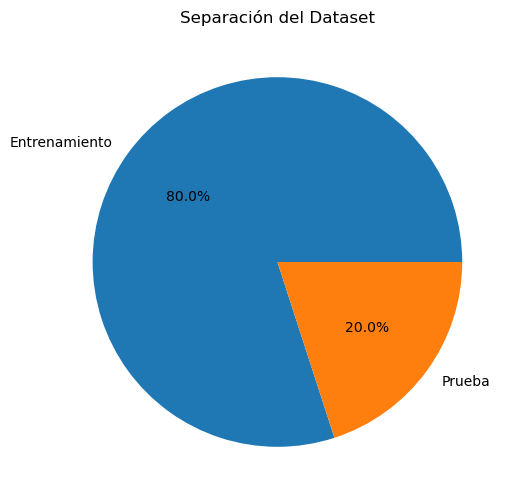

In [526]:
# ==========================================
# GRAFICA DE SEPARACIÓN DEL DATASET
# ==========================================

#Gráfica de pastel para mostrar la separación del dataset
fig, ax = plt.subplots(figsize=(6,6))

ax.pie(
    [X_train.shape[0], X_test.shape[0]],
    labels=["Entrenamiento", "Prueba"],
    autopct='%1.1f%%'
)

ax.set_title("Separación del Dataset")

plt.show()


===== DATOS ANTES DEL ESCALAMIENTO REGRESION =====



,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,3.746205,3.399863,1.562346,2.246015,4.425326
1,2.814210,2.624669,1.566530,1.456287,3.599228
2,2.810005,2.480731,1.453953,1.373716,3.519869
3,2.507972,2.317474,2.014903,1.355835,3.427839
4,2.705380,2.320425,1.368639,1.345472,3.398527
5,2.739549,2.073172,1.740466,1.178655,3.380314
6,2.371178,2.137710,1.635106,1.064711,3.187179
7,2.294553,2.200552,1.526056,1.147402,3.165475
8,2.773838,1.776646,0.215111,0.989541,3.129389
9,2.303585,2.250239,1.261298,1.018847,3.126322



===== DATOS DESPUÉS DEL ESCALAMIENTO REGRESION =====



,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,-0.782444,0.904579,1.182697,-0.268273,0.333313
1,-0.089172,-0.271169,-0.295899,-0.414577,-0.255613
2,2.138011,1.204264,-0.164682,1.055772,1.811496
3,0.103562,-0.271169,-0.295899,-0.414577,-0.112202
4,-0.375359,-0.564189,0.687563,-0.341067,-0.255613
5,-0.601411,-0.414888,-0.295899,-0.341067,-0.651269
6,-0.430349,-0.451673,-0.295899,-0.488820,-0.554914
7,-0.720920,-0.564189,-0.295899,-0.488820,-0.836078
8,-0.690609,-0.526316,3.374259,-0.414577,0.395463
9,-0.782444,-0.526316,-0.295899,-0.488820,-0.857602


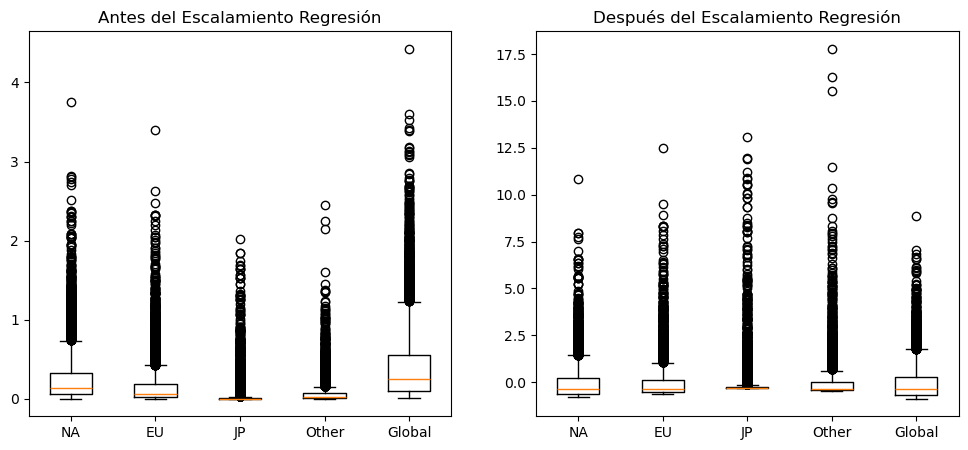

In [527]:
# ==========================================
# DATAFRAME CON DATOS ESCALADOS REGRESION
# ==========================================

y_train_reg_scaled_df = pd.DataFrame(
    y_train_reg_scaled,
    columns=[
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
)

# ==========================================
# DATAFRAME ANTES DEL ESCALAMIENTO
# ==========================================

before_scaling = vg_data[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
].astype(float)

# ==========================================
# DATAFRAME DESPUÉS DEL ESCALAMIENTO
# ==========================================

after_scaling = y_train_reg_scaled_df[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
].astype(float)

# ==========================================
# MOSTRAR TABLAS
# ==========================================

print("\n===== DATOS ANTES DEL ESCALAMIENTO REGRESION =====\n")
display(before_scaling.head(10))

print("\n===== DATOS DESPUÉS DEL ESCALAMIENTO REGRESION =====\n")
display(after_scaling.head(10))

# ==========================================
# GRAFICAR BOXPLOTS
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Antes del escalamiento
ax[0].boxplot(
    before_scaling.values
)

ax[0].set_title(
    "Antes del Escalamiento Regresión"
)

ax[0].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global"
])

# Después del escalamiento
ax[1].boxplot(
    after_scaling.values
)

ax[1].set_title(
    "Después del Escalamiento Regresión"
)

ax[1].set_xticklabels([
    "NA",
    "EU",
    "JP",
    "Other",
    "Global"
])

plt.show()


CREACION DEL MODELO EN BASE A TRAIN

In [528]:
# ==========================================
# MODELO DE REGRESIÓN
# ==========================================

regressor = MLPRegressor(

    hidden_layer_sizes=(32, 16),

    activation="relu",

    solver="adam",

    alpha=0.01,

    learning_rate_init=0.0005,

    max_iter=1000,

    early_stopping=True,

    validation_fraction=0.1,

    n_iter_no_change=20,

    random_state=42
)

# Entrenar red neuronal
regressor.fit(
    X_train,
    y_train_reg_scaled
)

MLPRegressor(alpha=0.01, early_stopping=True, hidden_layer_sizes=(32, 16),
             learning_rate_init=0.0005, max_iter=1000, n_iter_no_change=20,
             random_state=42)

In [529]:
# ==========================================
# MODELO DE CLASIFICACIÓN
# ==========================================

classifier = RandomForestClassifier(

    n_estimators=200,

    random_state=42,

    oob_score=True
)

classifier.fit(
    X_train,
    y_train_class
)

print("OOB Score Clasificación:", classifier.oob_score_)

OOB Score Clasificación: 0.3895236421163649


In [530]:
# ==========================================
# PREDICCIONES TRAIN
# ==========================================

# ---------- REGRESIÓN ----------

y_pred_reg_scaled = regressor.predict(
    X_train
)

# Regresar a escala original
y_pred_reg = scaler.inverse_transform(
    y_pred_reg_scaled
)

# ---------- CLASIFICACIÓN ----------

y_pred_class = classifier.predict(
    X_train
)

In [531]:
# ==========================================
# VALORES DE PREDICCIÓN EN TRAIN
# ==========================================

# Recuperar filas originales del CSV
train_original = vg_data.loc[
    y_train_reg.index
].copy()

# Valores reales convertidos a texto
critic_real_text = (
    label_encoder.inverse_transform(
        y_train_class.astype(int)
    )
)

# Valores predichos convertidos a texto
critic_pred_text = (
    label_encoder.inverse_transform(
        y_pred_class.astype(int)
    )
)

# ==========================================
# TABLA DE RESULTADOS
# ==========================================

resultados = pd.DataFrame({

    # Datos originales
    "Platform": train_original["Platform"].values,
    "Genre": train_original["Genre"].values,
    "Publisher": train_original["Publisher"].values,
    "Rating": train_original["Rating"].values,

    # ---------- REGRESIÓN ----------

    "Real NA": y_train_reg["NA_Sales"].values,
    "Pred NA": y_pred_reg[:, 0],

    "Real EU": y_train_reg["EU_Sales"].values,
    "Pred EU": y_pred_reg[:, 1],

    "Real JP": y_train_reg["JP_Sales"].values,
    "Pred JP": y_pred_reg[:, 2],

    "Real Other": y_train_reg["Other_Sales"].values,
    "Pred Other": y_pred_reg[:, 3],

    "Real Global": y_train_reg["Global_Sales"].values,
    "Pred Global": y_pred_reg[:, 4],

    # ---------- CLASIFICACIÓN ----------

    "Real Critic": critic_real_text,
    "Pred Critic": critic_pred_text

})

#Redondear columnas numéricas a 2 decimales
columnas_numericas = [

    "Real NA",
    "Pred NA",

    "Real EU",
    "Pred EU",

    "Real JP",
    "Pred JP",

    "Real Other",
    "Pred Other",

    "Real Global",
    "Pred Global"
]

resultados[columnas_numericas] = (
    resultados[columnas_numericas]
    .round(2)
)

styled_results = (

    resultados.head(20).style

    .set_properties(**{
        "text-align": "center",
        "font-size": "10pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=columnas_numericas
    )
)

styled_results

,Platform,Genre,Publisher,Rating,Real NA,Pred NA,Real EU,Pred EU,Real JP,Pred JP,Real Other,Pred Other,Real Global,Pred Global,Real Critic,Pred Critic
0,3DS,Puzzle,Nintendo,E10+,0.000000,0.180000,0.390000,0.150000,0.220000,0.210000,0.030000,0.020000,0.560000,0.410000,Excelente,Excelente
1,GBA,Action,Atari,T,0.220000,0.200000,0.090000,0.070000,0.000000,0.030000,0.010000,0.010000,0.290000,0.340000,Bueno,Bueno
2,X360,Shooter,Ubisoft,M,0.940000,0.570000,0.470000,0.350000,0.020000,0.020000,0.210000,0.130000,1.230000,0.820000,Excelente,Bueno
3,GC,Sports,Electronic Arts,E,0.290000,0.240000,0.090000,0.030000,0.000000,-0.020000,0.010000,-0.010000,0.360000,0.280000,Excelente,Excelente
4,PSP,Role-Playing,Square Enix,T,0.130000,0.240000,0.010000,0.160000,0.150000,0.290000,0.020000,0.080000,0.290000,0.590000,Bueno,Excelente
5,PS2,Platform,Ubisoft,E,0.060000,0.130000,0.050000,0.130000,0.000000,-0.010000,0.020000,0.040000,0.110000,0.280000,Malo,Bueno
6,GBA,Shooter,Electronic Arts,T,0.110000,0.220000,0.040000,0.090000,0.000000,0.000000,0.000000,0.020000,0.160000,0.310000,Bueno,Excelente
7,X,Adventure,Ubisoft,T,0.020000,0.190000,0.010000,0.050000,0.000000,0.010000,0.000000,-0.000000,0.030000,0.250000,Bueno,Bueno
8,PS2,Action,Sega,M,0.030000,0.160000,0.020000,0.140000,0.550000,0.030000,0.010000,0.080000,0.590000,0.350000,Bueno,Bueno
9,PC,Adventure,Ubisoft,E,0.000000,0.050000,0.020000,0.080000,0.000000,-0.010000,0.000000,0.010000,0.020000,0.150000,Bueno,Bueno


In [532]:
# ==========================================
# VARIABLES DE REGRESIÓN
# ==========================================

variables_regresion = [

    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

predicciones_regresion = y_pred_reg

# ==========================================
# MÉTRICAS POR CADA VARIABLE
# ==========================================

for i, variable in enumerate(variables_regresion):

    # Valores reales
    real = y_train_reg[variable]

    # Valores predichos
    pred = predicciones_regresion[:, i]

    mae = mean_absolute_error(
        real,
        pred
    )

    mse = mean_squared_error(
        real,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        real,
        pred
    )

    # ======================================
    # TABLA DE MÉTRICAS REGRESIÓN
    # ======================================

    tabla_metricas = pd.DataFrame({

        "Métrica": [
            "MAE",
            "MSE",
            "RMSE",
            "R² Score"
        ],

        "Valor": [
            mae,
            mse,
            rmse,
            r2
        ]
    })

    # Redondear valores
    tabla_metricas["Valor"] = (

        tabla_metricas["Valor"]
        .astype(float)
        .round(4)
    )

    print(f"\n===== MÉTRICAS DE {variable} TRAIN =====\n")

    styled_table = (

        tabla_metricas.style

        .set_properties(**{
            "text-align": "center",
            "font-size": "11pt"
        })

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1F4E78"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            }
        ])

        .background_gradient(
            cmap="Blues",
            subset=["Valor"]
        )
    )

    display(styled_table)

# ==========================================
# MÉTRICAS DE CLASIFICACIÓN
# ==========================================

# Valores reales
critic_real = y_train_class.values

# Valores predichos
critic_pred = y_pred_class

accuracy = accuracy_score(
    critic_real,
    critic_pred
)

precision = precision_score(
    critic_real,
    critic_pred,
    average="weighted"
)

recall = recall_score(
    critic_real,
    critic_pred,
    average="weighted"
)

f1 = f1_score(
    critic_real,
    critic_pred,
    average="weighted"
)

# ==========================================
# TABLA CLASIFICACIÓN
# ==========================================

tabla_clasificacion = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

# Redondear valores
tabla_clasificacion["Valor"] = (

    tabla_clasificacion["Valor"]
    .astype(float)
    .round(4)
)

print("\n===== MÉTRICAS DE Critic_Score_Class TRAIN =====\n")

styled_classification = (

    tabla_clasificacion.style

    .set_properties(**{
        "text-align": "center",
        "font-size": "11pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=["Valor"]
    )
)

display(styled_classification)



===== MÉTRICAS DE NA_Sales TRAIN =====



,Métrica,Valor
0,MAE,0.154200
1,MSE,0.057500
2,RMSE,0.239700
3,R² Score,0.445200



===== MÉTRICAS DE EU_Sales TRAIN =====



,Métrica,Valor
0,MAE,0.120800
1,MSE,0.041900
2,RMSE,0.204800
3,R² Score,0.380200



===== MÉTRICAS DE JP_Sales TRAIN =====



...

,Métrica,Valor
0,MAE,0.050500
1,MSE,0.011300
2,RMSE,0.106300
3,R² Score,0.371000



===== MÉTRICAS DE Global_Sales TRAIN =====



,Métrica,Valor
0,MAE,0.221000
1,MSE,0.108000
2,RMSE,0.328600
3,R² Score,0.474300



===== MÉTRICAS DE Critic_Score_Class TRAIN =====



,Métrica,Valor
0,Accuracy,0.746700
1,Precision,0.749500
2,Recall,0.746700
3,F1 Score,0.746600



===== MATRIZ DE CONFUSIÓN TRAIN =====



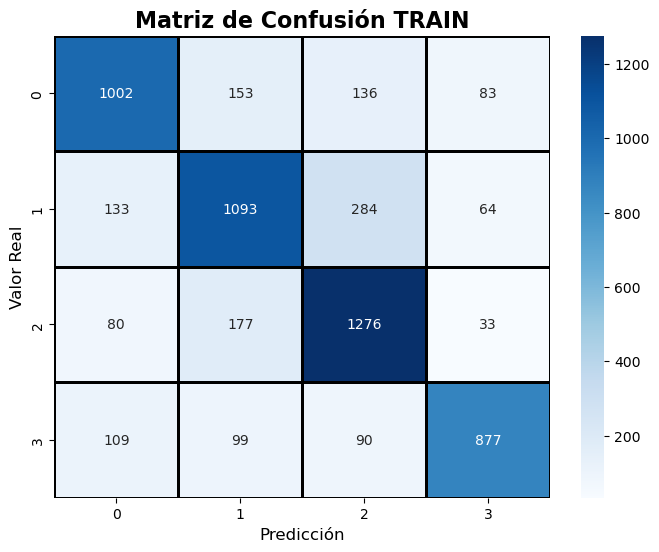

In [533]:
# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

# Valores reales
critic_real = y_train_class.values

# Predicciones del clasificador
critic_pred = classifier.predict(X_train)

# Crear matriz
matrix = confusion_matrix(
    critic_real,
    critic_pred
)

print("\n===== MATRIZ DE CONFUSIÓN TRAIN =====\n")

# ==========================================
# GRAFICAR MATRIZ
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=True
)

plt.title(
    "Matriz de Confusión TRAIN",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicción",
    fontsize=12
)

plt.ylabel(
    "Valor Real",
    fontsize=12
)

plt.show()

CREACION DEL MODELO EN BASE A TEST

In [534]:
# ==========================================
# PREDICCIONES REGRESIÓN TEST
# ==========================================

y_pred_scaled_test = regressor.predict(X_test)

y_pred_test = scaler.inverse_transform(
    y_pred_scaled_test
)

# ==========================================
# PREDICCIONES CLASIFICACIÓN TEST
# ==========================================

critic_pred_test = classifier.predict(X_test)

In [535]:
# ==========================================
# PREDICCIONES TRAIN
# ==========================================

# ---------- REGRESIÓN ----------

y_pred_reg_scaled_test = regressor.predict(
    X_test
)

# Regresar a escala original
y_pred_reg_test = scaler.inverse_transform(
    y_pred_reg_scaled_test
)

# ---------- CLASIFICACIÓN ----------

y_pred_class_test = classifier.predict(
    X_test
)

# ==========================================
# VALORES DE PREDICCIÓN EN TEST
# ==========================================

# Recuperar filas originales del CSV
test_original = vg_data.loc[
    y_test_reg.index
].copy()

# Valores reales convertidos a texto
critic_real_test_text = (
    label_encoder.inverse_transform(
        y_test_class.astype(int)
    )
)

# Valores predichos convertidos a texto
critic_pred_test_text = (
    label_encoder.inverse_transform(
        y_pred_class_test.astype(int)
    )
)

# ==========================================
# TABLA DE RESULTADOS
# ==========================================

resultados = pd.DataFrame({

    # Datos originales
    "Platform": test_original["Platform"].values,
    "Genre": test_original["Genre"].values,
    "Publisher": test_original["Publisher"].values,
    "Rating": test_original["Rating"].values,

    # ---------- REGRESIÓN ----------

    "Real NA": y_test_reg["NA_Sales"].values,
    "Pred NA": y_pred_reg_test[:, 0],

    "Real EU": y_test_reg["EU_Sales"].values,
    "Pred EU": y_pred_reg_test[:, 1],

    "Real JP": y_test_reg["JP_Sales"].values,
    "Pred JP": y_pred_reg_test[:, 2],

    "Real Other": y_test_reg["Other_Sales"].values,
    "Pred Other": y_pred_reg_test[:, 3],

    "Real Global": y_test_reg["Global_Sales"].values,
    "Pred Global": y_pred_reg_test[:, 4],

    # ---------- CLASIFICACIÓN ----------

    "Real Critic": critic_real_test_text,
    "Pred Critic": critic_pred_test_text

})

#Redondear columnas numéricas a 2 decimales
columnas_numericas = [

    "Real NA",
    "Pred NA",

    "Real EU",
    "Pred EU",

    "Real JP",
    "Pred JP",

    "Real Other",
    "Pred Other",

    "Real Global",
    "Pred Global"
]

resultados[columnas_numericas] = (
    resultados[columnas_numericas]
    .round(2)
)

styled_results = (

    resultados.head(20).style

    .set_properties(**{
        "text-align": "center",
        "font-size": "10pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=columnas_numericas
    )
)

styled_results

,Platform,Genre,Publisher,Rating,Real NA,Pred NA,Real EU,Pred EU,Real JP,Pred JP,Real Other,Pred Other,Real Global,Pred Global,Real Critic,Pred Critic
0,Wii,Action,D3Publisher,E10+,0.220000,0.220000,0.130000,0.090000,0.000000,0.030000,0.040000,0.020000,0.360000,0.320000,Aceptable,Malo
1,X360,Role-Playing,Square Enix,T,0.230000,0.390000,0.000000,0.190000,0.020000,0.150000,0.020000,0.080000,0.260000,0.610000,Aceptable,Bueno
2,PS2,Adventure,Indie Games,T,0.020000,0.040000,0.010000,0.010000,0.000000,0.020000,0.000000,0.010000,0.040000,0.110000,Aceptable,Malo
3,PS2,Action,Vivendi Games,E,0.170000,0.330000,0.130000,0.200000,0.000000,0.010000,0.050000,0.110000,0.310000,0.510000,Malo,Malo
4,DS,Action,Electronic Arts,E,0.070000,0.230000,0.000000,0.060000,0.000000,0.000000,0.010000,0.020000,0.070000,0.280000,Malo,Malo
5,X360,Racing,Codemasters,E,0.030000,0.240000,0.050000,0.240000,0.000000,0.000000,0.010000,0.070000,0.090000,0.430000,Bueno,Excelente
6,PSP,Role-Playing,Konami Digital Entertainment,E10+,0.040000,0.130000,0.000000,0.120000,0.000000,0.130000,0.000000,0.050000,0.050000,0.320000,Aceptable,Malo
7,GC,Role-Playing,Sega,T,0.060000,0.200000,0.020000,0.060000,0.000000,0.040000,0.000000,0.000000,0.080000,0.260000,Bueno,Malo
8,X360,Action,Ubisoft,M,1.420000,0.770000,0.940000,0.510000,0.080000,0.090000,0.420000,0.230000,1.840000,1.100000,Excelente,Excelente
9,GC,Platform,Electronic Arts,E,0.140000,0.270000,0.040000,0.110000,0.000000,-0.010000,0.010000,0.020000,0.180000,0.380000,Aceptable,Aceptable


In [536]:
# ==========================================
# VARIABLES DE REGRESIÓN
# ==========================================

variables_regresion = [

    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales"
]

predicciones_regresion = y_pred_reg_test

# ==========================================
# MÉTRICAS POR CADA VARIABLE
# ==========================================

for i, variable in enumerate(variables_regresion):

    # Valores reales
    real = y_test_reg[variable]

    # Valores predichos
    pred = predicciones_regresion[:, i]

    mae = mean_absolute_error(
        real,
        pred
    )

    mse = mean_squared_error(
        real,
        pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        real,
        pred
    )

    # ======================================
    # TABLA DE MÉTRICAS REGRESIÓN
    # ======================================

    tabla_metricas = pd.DataFrame({

        "Métrica": [
            "MAE",
            "MSE",
            "RMSE",
            "R² Score"
        ],

        "Valor": [
            mae,
            mse,
            rmse,
            r2
        ]
    })

    # Redondear valores
    tabla_metricas["Valor"] = (

        tabla_metricas["Valor"]
        .astype(float)
        .round(4)
    )

    print(f"\n===== MÉTRICAS DE {variable} TEST =====\n")

    styled_table = (

        tabla_metricas.style

        .set_properties(**{
            "text-align": "center",
            "font-size": "11pt"
        })

        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1F4E78"),
                    ("color", "white"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            }
        ])

        .background_gradient(
            cmap="Blues",
            subset=["Valor"]
        )
    )

    display(styled_table)

# ==========================================
# MÉTRICAS DE CLASIFICACIÓN
# ==========================================

# Valores reales
critic_real_test = y_test_class.values

# Valores predichos
critic_pred_test = y_pred_class_test

accuracy = accuracy_score(
    critic_real_test,
    critic_pred_test
)

precision = precision_score(
    critic_real_test,
    critic_pred_test,
    average="weighted"
)

recall = recall_score(
    critic_real_test,
    critic_pred_test,
    average="weighted"
)

f1 = f1_score(
    critic_real_test,
    critic_pred_test,
    average="weighted"
)

# ==========================================
# TABLA CLASIFICACIÓN
# ==========================================

tabla_clasificacion = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Valor": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

# Redondear valores
tabla_clasificacion["Valor"] = (

    tabla_clasificacion["Valor"]
    .astype(float)
    .round(4)
)

print("\n===== MÉTRICAS DE Critic_Score_Class TEST =====\n")

styled_classification = (

    tabla_clasificacion.style

    .set_properties(**{
        "text-align": "center",
        "font-size": "11pt"
    })

    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E78"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])

    .background_gradient(
        cmap="Blues",
        subset=["Valor"]
    )
)

display(styled_classification)



===== MÉTRICAS DE NA_Sales TEST =====



,Métrica,Valor
0,MAE,0.183000
1,MSE,0.074200
2,RMSE,0.272300
3,R² Score,0.303000



===== MÉTRICAS DE EU_Sales TEST =====



,Métrica,Valor
0,MAE,0.147700
1,MSE,0.054800
2,RMSE,0.234100
3,R² Score,0.236900



===== MÉTRICAS DE JP_Sales TEST =====



...

,Métrica,Valor
0,MAE,0.059300
1,MSE,0.011900
2,RMSE,0.109000
3,R² Score,0.272900



===== MÉTRICAS DE Global_Sales TEST =====



,Métrica,Valor
0,MAE,0.270700
1,MSE,0.146800
2,RMSE,0.383100
3,R² Score,0.312600



===== MÉTRICAS DE Critic_Score_Class TEST =====



,Métrica,Valor
0,Accuracy,0.418100
1,Precision,0.414400
2,Recall,0.418100
3,F1 Score,0.415200



===== MATRIZ DE CONFUSIÓN TEST =====



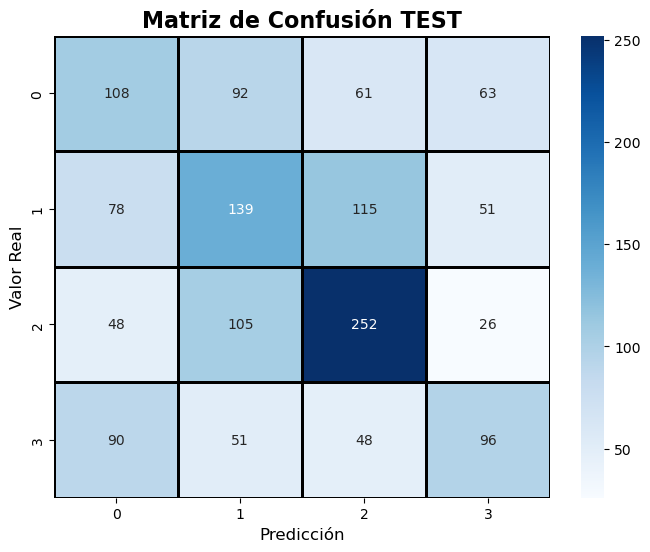

In [537]:
# ==========================================
# MATRIZ DE CONFUSIÓN
# ==========================================

# Valores reales
critic_real = y_test_class.values

# Predicciones del clasificador
critic_pred = classifier.predict(X_test)

# Crear matriz
matrix = confusion_matrix(
    critic_real,
    critic_pred
)

print("\n===== MATRIZ DE CONFUSIÓN TEST =====\n")

# ==========================================
# GRAFICAR MATRIZ
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=True
)

plt.title(
    "Matriz de Confusión TEST",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicción",
    fontsize=12
)

plt.ylabel(
    "Valor Real",
    fontsize=12
)

plt.show()